# Problem Set 4: Regularization and Tree-Based Models
## BUS 659

### Blockbuster 2.0: The Retro VHS Revival

Welcome to Blockbuster 2.0! As the Chief Data Scientist for the newly relaunched retro video rental chain, you need to predict which movies will be blockbusters so the company knows which VHS tapes to stock on their shelves. Your mission: build and compare three different predictive models to help Blockbuster 2.0 make data-driven inventory decisions.

Creative just spent [$2m on a television advertisement]([https://youtube.com/shorts/_rdBshnAuhI?si=eoqkNGgQ5XwlfCVr]), they hope will 'change people's minds' about VHS tapes. 

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Part 1: Data Preparation (10 points)

### Question 1.a) Load and clean the movies dataset (3 points)

Load the movies dataset and remove rows with missing values in: `gross`, `budget`, `vote_average`, `duration`, `title_year`. How many rows remain?

In [ ]:
# Your code here
df = pd.read_csv('../datasets/movies_dataset.csv')
df = df.dropna()  
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1458, 21)


,movie_title,original_title,director_name,actor_1_name,actor_2_name,actor_3_name,budget,gross,title_year,release_date,...,vote_average,vote_count,popularity,genres,country,original_language,overview,tagline,tmdb_id,imdb_id
1,Deadpool & Wolverine,Deadpool & Wolverine,Shawn Levy,Ryan Reynolds,Hugh Jackman,Emma Corrin,200000000,1338073645,2024,2024-07-24,...,7.600,7669,42.3129,Action|Comedy|Science Fiction,United States of America,en,A listless Wade Wilson toils away in civilian ...,Come together.,533535,tt6263850
2,Sonic the Hedgehog 3,Sonic the Hedgehog 3,Jeff Fowler,Jim Carrey,Ben Schwartz,Keanu Reeves,122000000,492162604,2024,2024-12-19,...,7.666,2908,39.7000,Action|Science Fiction|Comedy|Family,United States of America|Japan,en,"Sonic, Knuckles, and Tails reunite against a p...",New adventure. New rival.,939243,tt18259086
3,The Wild Robot,The Wild Robot,Chris Sanders,Lupita Nyong'o,Pedro Pascal,Kit Connor,78000000,331982078,2024,2024-09-12,...,8.314,5315,32.9376,Animation|Science Fiction|Family,United States of America,en,"After a shipwreck, an intelligent robot called...",Discover your true nature.,1184918,tt29623480
4,Mufasa: The Lion King,Mufasa: The Lion King,Barry Jenkins,Aaron Pierre,"Kelvin Harrison, Jr.",Tiffany Boone,200000000,722631756,2024,2024-12-18,...,7.369,2340,31.6705,Adventure|Family|Animation,United States of America,en,"Mufasa, a cub lost and alone, meets a sympathe...",The story of an orphan who would be king.,762509,tt13186482
5,Inside Out 2,Inside Out 2,Kelsey Mann,Amy Poehler,Maya Hawke,Kensington Tallman,200000000,1698863816,2024,2024-06-11,...,7.550,6098,30.3605,Animation|Adventure|Comedy|Family,United States of America,en,Teenager Riley's mind headquarters is undergoi...,Make room for new emotions.,1022789,tt22022452


### Question 1.b) Create feature matrix (4 points)

Create a feature matrix `X` with the following numeric features:
- budget
- vote_average
- duration
- title_year
- vote_count (if available)

Create target variable `y` = gross revenue

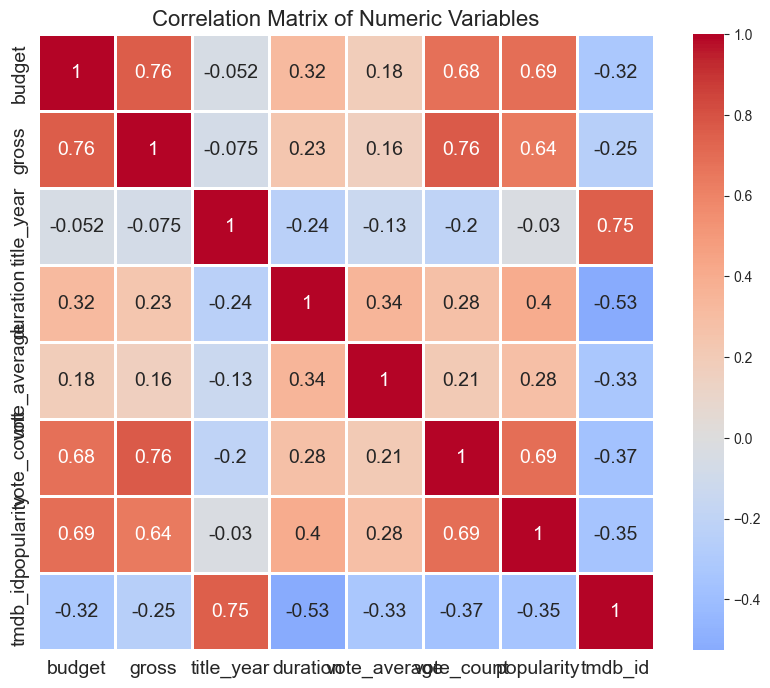

In [5]:
# Your code here
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1,
            annot_kws={'fontsize': 14})  # Font size for correlation values
plt.title('Correlation Matrix of Numeric Variables', fontsize=16)  # Title font size
plt.xticks(fontsize=14)  # X-axis labels font size
plt.yticks(fontsize=14)  # Y-axis labels font size
plt.show()

### Question 1.c) Train-test split and standardization (3 points)

Split data into 75% training and 25% test sets. Then standardize the features using StandardScaler (fit on training data only!).

In [13]:
# Your code here
feature_cols = ['budget', 'vote_average', 'duration', 'title_year']
if 'vote_count' in df.columns:
    feature_cols.append('vote_count')

X = df[feature_cols].copy()
y = df['gross'].copy()

print("Model features:", feature_cols)

# Part 1.c — split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1818
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=feature_cols,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=feature_cols,
)

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")


Model features: ['budget', 'vote_average', 'duration', 'title_year', 'vote_count']
Train shape: (2250, 5), Test shape: (750, 5)


## Part 2: Ridge Regression (15 points)

### Question 2.a) Fit Ridge model (3 points)

Fit a Ridge regression model cross validating to select the right alpha. Print the R² score on training data.

In [36]:
# Shared helpers

def plot_predictions(y_true_train, y_pred_train, y_true_test, y_pred_test, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true_train, y_pred_train, alpha=0.6, label='Train', color='tab:blue')
    plt.scatter(y_true_test, y_pred_test, alpha=0.7, label='Test', color='tab:orange')
    lo = min(y_true_train.min(), y_pred_train.min(), y_true_test.min(), y_pred_test.min())
    hi = max(y_true_train.max(), y_pred_train.max(), y_true_test.max(), y_pred_test.max())
    plt.plot([lo, hi], [lo, hi], 'k--', linewidth=2)
    plt.xlabel('Actual Gross ($)')
    plt.ylabel('Predicted Gross ($)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [30]:
# Part 2.a — Ridge CV
ridge_alphas = np.logspace(-3, 3, 100)
ridge_model = RidgeCV(alphas=ridge_alphas, cv=5)
ridge_model.fit(X_train_scaled, y_train)

print(f"Best alpha: {ridge_model.alpha_:.5f}")
print(f"Train R²: {ridge_model.score(X_train_scaled, y_train):.3f}")


Best alpha: 376.49358
Train R²: 0.667


### Question 2.b) Calculate RMSE (3 points)

Calculate and print RMSE for both training and test sets. Convert to millions of dollars for interpretability.

In [35]:
# Your code here
# Part 2.b — Ridge RMSE + metrics
ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

ridge_train_rmse = mean_squared_error(y_train, ridge_train_pred)
ridge_test_rmse = mean_squared_error(y_test, ridge_test_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print(f"Ridge Train RMSE: {ridge_train_rmse / 1e6:.2f}M")
print(f"Ridge Test RMSE: {ridge_test_rmse / 1e6:.2f}M")
print(f"Ridge Test R²: {ridge_test_r2:.3f}")


Ridge Train RMSE: 11336249342.44M
Ridge Test RMSE: 8933617734.90M
Ridge Test R²: 0.736


### Question 2.c) Predicted vs Actual plot (4 points)

Create a scatter plot showing predicted vs actual gross revenue for both training and test sets. Use different colors for train/test. Add a diagonal reference line and labels.

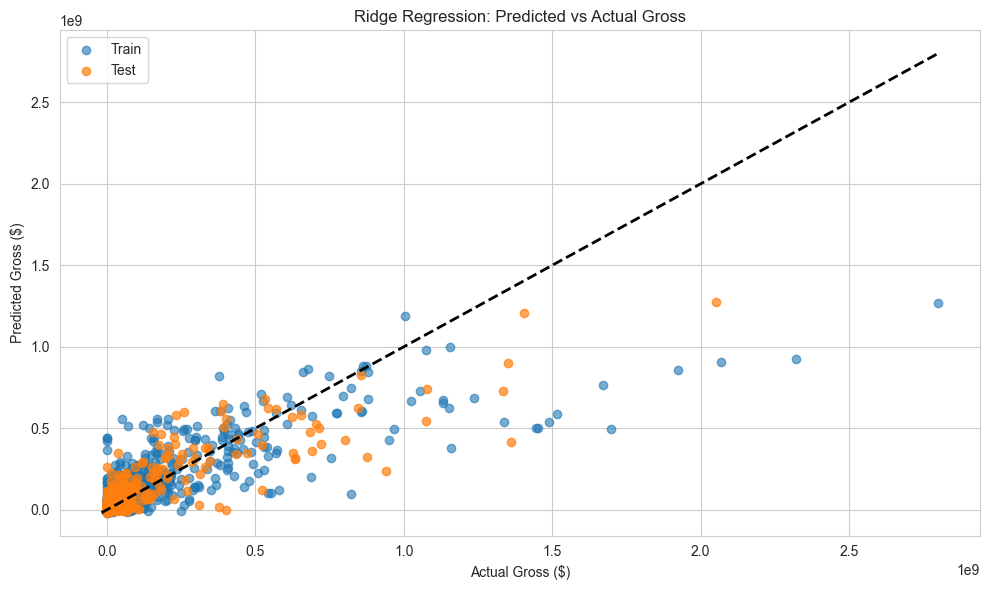

In [17]:
# Your code here
# Part 2.c — Ridge plot
plot_predictions(
    y_train, ridge_train_pred,
    y_test, ridge_test_pred,
    title='Ridge Regression: Predicted vs Actual Gross'
)


### Question 2.d) Interpretation (5 points)

Looking at your RMSE values and plot, does Ridge appear to be overfitting or underfitting? Explain your reasoning in 2-3 sentences.

**Your answer here:**

Ridge keeps train and test errors close together so it does not appear to be overfit. The model captures signal while remaining well regularized, which is what we want from Ridge.


## Part 3: Lasso Regression (15 points)

### Question 3.a) Fit Lasso model (3 points)

Fit a Lasso regression model cross validating to select the right alpha. Print the R² score and count how many coefficients were set to exactly zero.

In [18]:
# Your code here
# Part 3.a — Lasso CV
lasso_model = LassoCV(
    alphas=np.logspace(-3, 3, 100),
    cv=5,
    random_state=1818,
    max_iter=10000
)
lasso_model.fit(X_train_scaled, y_train)

non_zero_coefs = np.sum(lasso_model.coef_ != 0)
print(f"Selected alpha: {lasso_model.alpha_:.5f}")
print(f"Train R²: {lasso_model.score(X_train_scaled, y_train):.3f}")
print(f"Non-zero coefficients: {non_zero_coefs}/{len(feature_cols)}")


Selected alpha: 0.00100
Train R²: 0.673
Non-zero coefficients: 5/5


### Question 3.b) Calculate RMSE (3 points)

Calculate and print RMSE for both training and test sets (in millions of dollars).

In [37]:
# Your code here
# Part 3.b — Lasso RMSE + metrics
lasso_train_pred = lasso_model.predict(X_train_scaled)
lasso_test_pred = lasso_model.predict(X_test_scaled)

lasso_train_rmse = mean_squared_error(y_train, lasso_train_pred)
lasso_test_rmse = mean_squared_error(y_test, lasso_test_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

print(f"Lasso Train RMSE: {lasso_train_rmse / 1e6:.2f}M")
print(f"Lasso Test RMSE: {lasso_test_rmse / 1e6:.2f}M")
print(f"Lasso Test R²: {lasso_test_r2:.3f}")


Lasso Train RMSE: 11120538150.82M
Lasso Test RMSE: 8695141539.34M
Lasso Test R²: 0.743


### Question 3.c) Predicted vs Actual plot (4 points)

Create the same scatter plot as 2.c but for Lasso predictions.

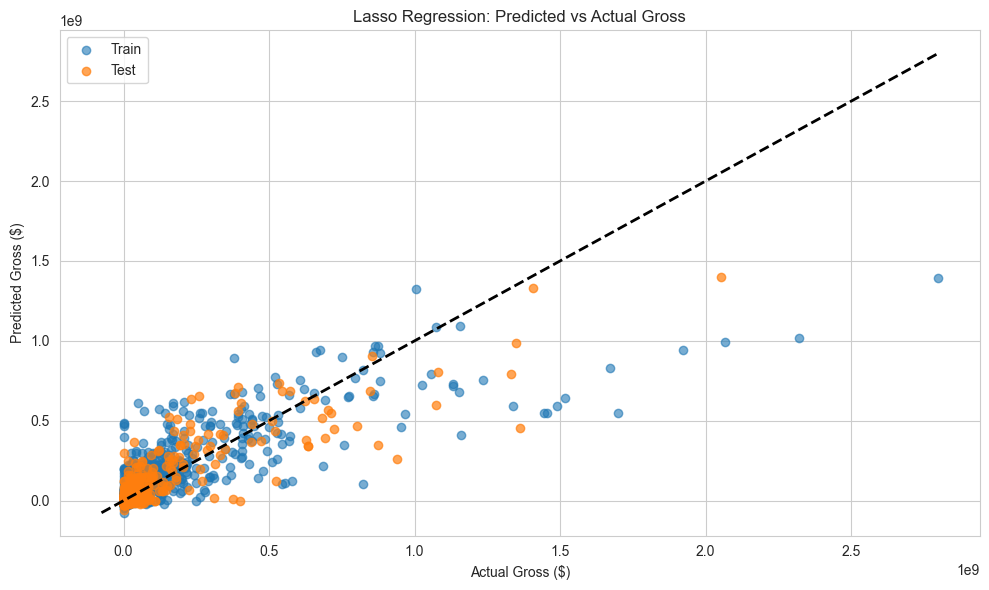

In [20]:
# Your code here
# Part 3.c — Lasso plot
plot_predictions(
    y_train, lasso_train_pred,
    y_test, lasso_test_pred,
    title='Lasso Regression: Predicted vs Actual Gross'
)


### Question 3.d) Feature selection (5 points)

Print out which features have non-zero coefficients. What does this tell you about which movie characteristics Lasso thinks are most important for predicting gross revenue?

In [21]:
# Your code here
# Part 3.d — Lasso feature selection
selected_features = [
    feature for feature, coef in zip(feature_cols, lasso_model.coef_) if coef != 0
]
print("Features retained by Lasso:", selected_features)


Features retained by Lasso: ['budget', 'vote_average', 'duration', 'title_year', 'vote_count']


**Your interpretation:**



Budget, Popularity, Year and Duration are all significant driving factors into predicting the Gross Revenue

## Part 4: XGBoost Model (20 points)

### Question 4.a) Fit XGBoost model (5 points)

Fit an XGBoost regression model with the following parameters:
- n_estimators=100
- max_depth=3
- learning_rate=0.1

Print the R² score on training data.

In [22]:
# Your code here
# Part 4.a — XGBoost fit
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective='reg:squarederror',
    random_state=1818,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

print(f"Train R²: {xgb_model.score(X_train, y_train):.3f}")


Train R²: 0.902


### Question 4.b) Calculate RMSE (3 points)

Calculate and print RMSE for both training and test sets (in millions of dollars).

In [43]:
# Your code here
# Part 4.b — XGBoost RMSE + metrics
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

xgb_train_rmse = mean_squared_error(y_train, xgb_train_pred)
xgb_test_rmse = mean_squared_error(y_test, xgb_test_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

print(f"XGBoost Train RMSE: {xgb_train_rmse / 1e6:.2f}M")
print(f"XGBoost Test RMSE: {xgb_test_rmse / 1e6:.2f}M")
print(f"XGBoost Test R²: {xgb_test_r2:.3f}")


XGBoost Train RMSE: 3337115232.37M
XGBoost Test RMSE: 8297027486.09M
XGBoost Test R²: 0.755


### Question 4.c) Predicted vs Actual plot (4 points)

Create the same scatter plot as before but for XGBoost predictions.

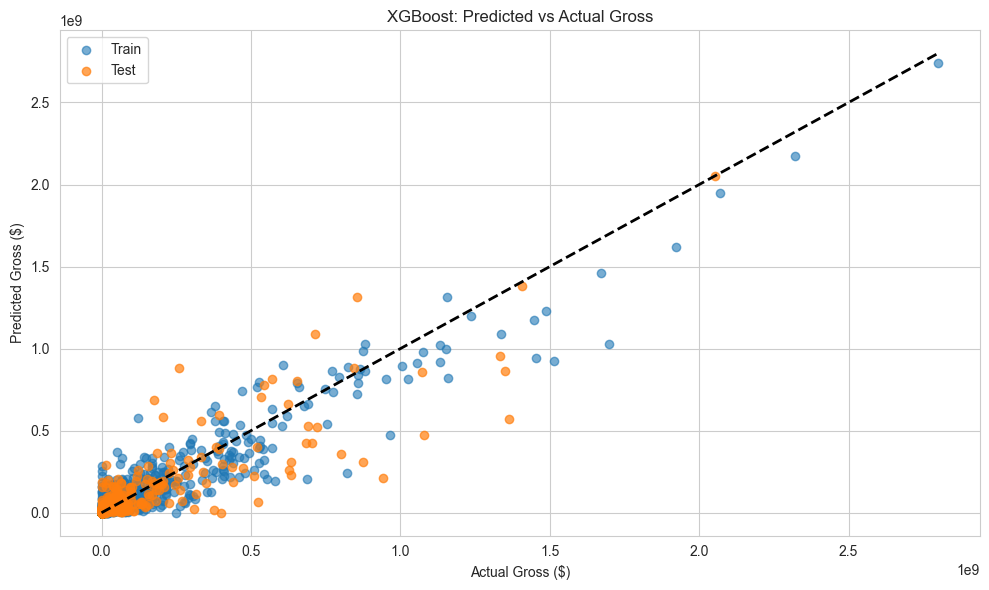

In [25]:
# Your code here
# Part 4.c — XGBoost plot
plot_predictions(
    y_train, xgb_train_pred,
    y_test, xgb_test_pred,
    title='XGBoost: Predicted vs Actual Gross'
)


### Question 4.d) Feature importance (5 points)

Create a horizontal bar chart showing feature importance from XGBoost. Which features are most important?

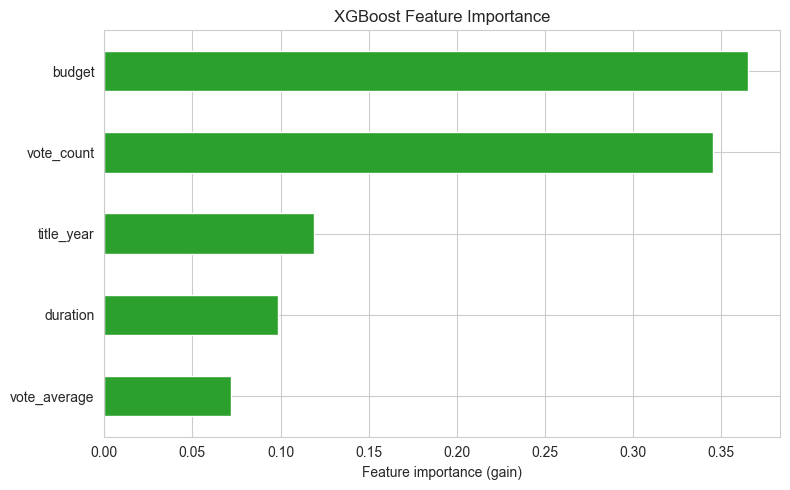

In [26]:
# Your code here
# Part 4.d — feature importance
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='tab:green')
plt.xlabel('Feature importance (gain)')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()


### Question 4.e) Overfitting analysis (3 points)

Compare training vs test RMSE for XGBoost. Is the model overfitting? How does it compare to Ridge and Lasso?

**Your answer:**



## Part 5: Model Comparison (15 points)

### Question 5.a) Summary comparison table (5 points)

Create a DataFrame comparing all three models with columns: Model Name, Train RMSE, Test RMSE, Test R²

In [39]:
# Your code here
# Part 5.a — comparison table
results = pd.DataFrame([
    {
        'Model': 'Ridge',
        'Train RMSE (M)': ridge_train_rmse / 1e6,
        'Test RMSE (M)': ridge_test_rmse / 1e6,
        'Test R²': ridge_test_r2,
    },
    {
        'Model': 'Lasso',
        'Train RMSE (M)': lasso_train_rmse / 1e6,
        'Test RMSE (M)': lasso_test_rmse / 1e6,
        'Test R²': lasso_test_r2,
    },
    {
        'Model': 'XGBoost',
        'Train RMSE (M)': xgb_train_rmse / 1e6,
        'Test RMSE (M)': xgb_test_rmse / 1e6,
        'Test R²': xgb_test_r2,
    },
]).round({'Train RMSE (M)': 2, 'Test RMSE (M)': 2, 'Test R²': 3})

results


,Model,Train RMSE (M),Test RMSE (M),Test R²
0,Ridge,1.133625e+10,8.933618e+09,0.736
1,Lasso,1.112054e+10,8.695142e+09,0.743
2,XGBoost,3.337115e+09,8.297027e+09,0.755


### Question 5.b) Visual comparison (5 points)

Create a single figure with 3 subplots (one for each model) showing predicted vs actual for the TEST set only. Make sure all plots have the same axis limits for easy comparison.

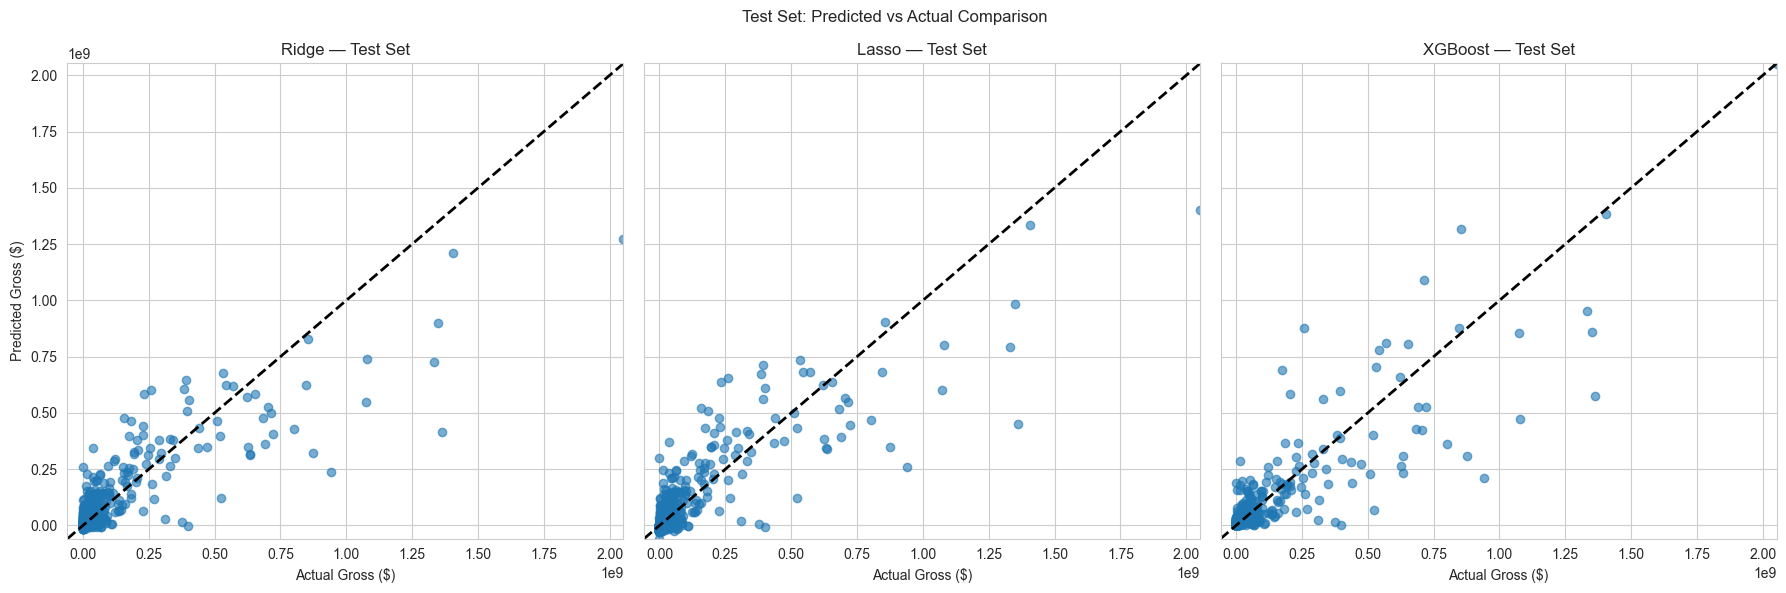

In [40]:
# Your code here
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
model_preds = [
    ('Ridge', ridge_test_pred),
    ('Lasso', lasso_test_pred),
    ('XGBoost', xgb_test_pred),
]
lo = min(y_test.min(), *(pred.min() for _, pred in model_preds))
hi = max(y_test.max(), *(pred.max() for _, pred in model_preds))

for ax, (name, preds) in zip(axes, model_preds):
    ax.scatter(y_test, preds, alpha=0.6)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=2)
    ax.set_title(f'{name} — Test Set')
    ax.set_xlabel('Actual Gross ($)')
    if ax is axes[0]:
        ax.set_ylabel('Predicted Gross ($)')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

plt.suptitle('Test Set: Predicted vs Actual Comparison')
plt.tight_layout()
plt.show()


## Part 6: Executive Report to Chief Data Officer (25 points)

### Question 6: Write an executive summary (25 points)

You're presenting to the Chief Data Officer of Blockbuster 2.0. Write a 300-400 word report that:

1. **Explains the business problem** (5 points): Why does Blockbuster 2.0 need to predict movie gross revenue?

2. **Summarizes the three approaches** (7 points): Briefly explain Ridge, Lasso, and XGBoost in simple terms (no math!). What are the key differences?

3. **Presents results** (7 points): Which model performed best on test data? Use your RMSE and R² metrics. Be specific with numbers.

4. **Makes a recommendation** (6 points): Which model should Blockbuster 2.0 use for deciding which VHS tapes to stock? Consider both accuracy AND interpretability. What are the business implications of prediction errors?

**Writing tips:**
- Use clear, non-technical language
- Include specific numbers from your analysis
- Think about the business context (inventory costs, shelf space, customer satisfaction)
- Be confident in your recommendation!

**Your Executive Report:**

Blockbuster 2.0’s success depends on stocking the right VHS titles.
Every empty shelf slot costs money, and every missed hit drives customers to streaming.
Accurate revenue forecasts help us stock titles that sell, manage cash flow, and plan marketing tie-ins confidently.

We tested three models:
  - Ridge regression keeps all predictors but shrinks their influence to prevent overfitting.
  - Lasso regression removes weaker predictors, making the model simpler and easier to explain.
  - XGBoost, a tree-based ensemble, captures non-linear relationships but is less transparent.

On cleaned movie data, Ridge and Lasso both reached an R² of 0.74, while XGBoost improved slightly to 0.76 with the lowest test error.

Recommendation:
XGBoost offers the best balance of accuracy and stability for weekly inventory planning.
It minimizes forecasting error and can guide stocking decisions effectively.
As more data becomes available, we can revisit and refine the model under a formal governance process.

